# Spectral Energy Distribution Modeling Module

SED modeling is a technique used to interpret the broadband and spectroscopic light from galaxies in order to infer their physical properties. By fitting observed fluxes across multiple wavelengths with models that account for stellar populations, dust attenuation, and nebular emission, SED modeling provides estimates of stellar mass, star-formation history, age, metallicity, and dust content. 

### Objective
Measure stellar population properties of FRB host galaxies using state-of-the-art SED modeling techniques.

### Required dependencies
All the software required for today's tutorials should be readily accessible in the docker containers. At a later epoch, should you choose to do so, nominally, you should be able to install the python modules on your computer with `pip install <module>`. Here, we link to the official webpages of all the software for future reference.

* [fsps](https://python-fsps.readthedocs.io/en/latest/installation/), which governs the fundamental stellar population synthesis models (via the python-fsps package),
* [sedpy](https://sedpy.readthedocs.io/en/latest/installation.html), which contains routines for projecting spectra onto filter bandpasses, and
* [prospect](https://prospect.readthedocs.io/en/stable/), which is where the likelihood evaluations, parameter priors, and posterior sampling takes place.

`Prospector` ([Leja+2017](https://ui.adsabs.harvard.edu/abs/2017ApJ...837..170L), [Johnson+2021](https://ui.adsabs.harvard.edu/abs/2021ApJS..254...22J)) is a state-of-the-art Bayesian inference framework for SED modeling. It couples flexible parameterizations of galaxy properties with the stellar population synthesis code `FSPS` ([Conroy+2009](https://ui.adsabs.harvard.edu/abs/2009ApJ...699..486C), [Conroy+2010](https://ui.adsabs.harvard.edu/abs/2010ascl.soft10043C)), and employs efficient sampling algorithms to explore parameter space. `Prospector` is widely used to model galaxy photometry and 
spectra, quantify uncertainties, and place physically motivated priors on galaxy formation and evolution parameters.  

The following cell imports all of these packages for this module. Kindly ensure all these imports go through successfully. If you encounter any issues with the software, please reach out to the nearest Docker expert for assistance.


In [1]:
# set up some environmental dependencies
import os
import pickle
from tqdm import tqdm
import numpy as np
import pandas as pd
from astropy.io import ascii
import matplotlib.pyplot as plt
from matplotlib.pyplot import *
import seaborn as sns
from scipy.stats import truncnorm

import astropy.cosmology.units as cu
from astropy.cosmology import WMAP9 as cosmo

os.environ['SPS_HOME'] = "/Users/krittisharma/Desktop/research/fsps"
import sedpy
from sedpy.observate import getSED
from prospect.models import priors
from prospect.utils.obsutils import fix_obs
from prospect.models.sedmodel import SedModel, PolySedModel
from prospect.models.templates import TemplateLibrary
from prospect.sources.constants import lightspeed, jansky_cgs, cosmo, jansky_cgs, to_cgs_at_10pc
from prospect.fitting import lnprobfn, fit_model
from prospect.plotting.sfh import nonpar_recent_sfr, ratios_to_sfrs
import prospect.io.read_results as reader
import prospect.io.write_results as writer

import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger().setLevel(logging.ERROR)

plt.rcParams.update(
    {
        'text.usetex': False,
        'font.family': 'stixgeneral',
        'mathtext.fontset': 'stix',
    }
)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['image.origin'] = 'lower'
sns.set_context('talk')
sns.set(font_scale=1.4)
sns.set_palette('colorblind')
sns.set_style('ticks')
plt.rcParams["font.family"] = "Times New Roman"
cmap = matplotlib.cm.get_cmap('rainbow')


## Setup
Prospector requires several ingredients to conduct a fit. These are:

* An **obs dictionary** (with the data we intend to fit)
* A **stellar population synthesis object** (a source) to predict spectra from parameters
* A **model object** (to describe, store, and translate parameters and priors)
* A **likelihood** or posterior probability function
* It can also useful to collect the **meta-parameters** controlling how these ingredients are created and how the fit is conducted in a run_params dictionary. We will do that as we go along. We will also encapsulate each step of the setup in a series of build_x() functions.


In [2]:
# Observed properties of Mizu's host galaxies are stored in frb_obs.csv file
frbs_db = pd.read_csv("data/frb_obs.csv")
frbs_db.to_dict()

# store some meta-parameters that control the input arguments to this method
run_params = {}
run_params["zred"] = 0.0368 # Redshift estimate from pPXF


## The data to be fit: build_obs()
The data to be fit is stored in a dictionary that we will call `obs`. The `obs` dictionary stores the observed fluxes, uncertainties, and information about how those fluxes were measured. For spectra this means the wavelengths at which the fluxes were measured, while for photometry we must know the filters through which the fluxes were measured. This information is passed (via the `obs` dictionary) to the model object to specify which data to predict. It is also passed to the likelihood functions for calculating the likelihood of the data for a given model.

**Units**: The units of the fluxes and uncertainties are assumed to be maggies (i.e Jy/3631). The wavelength units are assumed to be observed frame vacuum angstroms. Also note that mask values should be True for data that you want to fit, and False for data that is to be ignored in the likelihood calculation.

We will create an `obs` dictionary below, with all of the required keys. We will do this through a `build_obs` method, that takes some meta-parameters.

In [3]:
def build_obs(filternames, # List of filter names
              mags, # Array of magnitudes
              mags_unc, # Array of uncertainties in magnitudes
              phot_mask, # Boolean mask indicating which photometric observations should be included in the analysis 
              wavelen=None, # Wavelength array
              flux=None, # Flux array
              flux_unc=None, # Uncertainty in flux array
              mask=None, # Mask array
              **extras): # Additional keyword arguments
    """
    Returns:
    --------
    obs         : dict
        Dictionary containing observational data including filters, maggies, maggies_unc, phot_mask, 
        phot_wave, wavelength, spectrum, unc, mask, and optionally normalized spectrum.
    """
    
    obs = {}
    obs["filters"] = sedpy.observate.load_filters(filternames) # Load filters

    # Calculate maggies and uncertainties
    obs["maggies"] = 10**(-0.4 * mags)
    obs["maggies_unc"] = (((10**(0.4 * mags_unc)) - 1) * obs["maggies"])

    # Store photometric mask and effective wavelengths
    obs["phot_mask"] = phot_mask
    obs["phot_wave"] = np.array([f.wave_effective for f in obs["filters"]])

    # Store spectrum data
    obs["wavelength"] = wavelen
    obs["spectrum"] = flux
    obs['unc'] = flux_unc
    obs['mask'] = mask

    # Normalize spectrum
    obs = normalize_ggc_spec(obs, norm_band='ps1_r')

    return obs


def normalize_ggc_spec(obs, # Dictionary containing observation data including wavelength, spectrum, filters, maggies, uncertainties, and optionally sky background.
                       norm_band): # Name of the photometric band to which the spectrum will be normalized.
    """
    Returns:
    -------
    obs       : dict
        Modified observation dictionary with the spectrum normalized to the specified band.
    """
    
    # Extract necessary information from observation dictionary
    bands = [f.name for f in obs['filters']]
    norm_index = bands.index(norm_band)

    # Calculate synthetic photometry
    synphot = getSED(obs['wavelength'], obs['spectrum'], obs['filters'])
    synphot = np.atleast_1d(synphot)

    # Compute normalization factor
    norm = 10**(-0.4 * synphot[norm_index]) / obs['maggies'][norm_index]

    # Convert spectrum to maggies and normalize
    wave = obs["wavelength"]
    flambda_to_maggies = wave * (wave/lightspeed) / jansky_cgs / 3631
    maggies = obs["spectrum"] / norm * flambda_to_maggies
    obs["spectrum"] = maggies

    # Normalize uncertainties
    obs["unc"] = obs["unc"] / norm * flambda_to_maggies

    # Store the normalized band information
    obs["norm_band"] = norm_band

    return obs



In [4]:
filterset = ['galex_FUV', 'galex_NUV',
             'ps1_g', 'decam_g', 'ps1_r', 'decam_r', 'ps1_i', 'ps1_z', 'decam_z', 'ps1_y',
             'sdss_u0', 'sdss_g0', 'sdss_r0', 'sdss_i0', 'sdss_z0',
             'wasp_g0', 'wasp_r0', 'wasp_i0', 'wasp_z0',
             'LRIS_V', 'LRIS_R', 'LRIS_G', 'DEIMOS_R',
             'twomass_J', 'twomass_H', 'twomass_Ks',
             'wirc_J', 'wirc_H', 'wirc_Ks',
             'wise_w1', 'wise_w2', 'wise_w3', 'wise_w4']

# Magnitudes feeded into this pipeline are already corrected for dust extinction and AB magnitude system corrections
mags = []; mags_unc = []; filternames = []; color_idx = []
for filt in filterset:
    if frbs_db[filt][0] != -99 and frbs_db[filt][0] != -100:
        filternames.append(filt)
        mags.append(frbs_db[filt][0])
        mags_unc.append(float(frbs_db[filt+"_err"][0]))
        color_idx.append(np.where(np.array(filterset) == filt)[0][0])

# Boolean mask indicating which photometric observations should be included in the analysis 
phot_mask = [True for i in range(len(mags))]

# Read in spectrum data
data = pd.read_csv('data/spec.csv')
wavelen = np.asarray(data["wavelen"], dtype="float")
flux = np.asarray(data["flux"]*(10**23)*data["wavelen"] * (data["wavelen"]*10**-8)/((3*10**10)*3631), dtype="float")
flux_unc = np.asarray(data["flux_unc"]*(10**23)*data["wavelen"] * (data["wavelen"]*10**-8)/((3*10**10)*3631), dtype="float")
mask = data["mask"]

obs = build_obs(filternames=filternames,
                mags=np.array(mags),
                mags_unc=np.array(mags_unc),
                phot_mask=phot_mask,
                wavelen=wavelen,
                flux=flux,
                flux_unc=flux_unc,
                mask=mask)

obs


{'filters': [<class 'sedpy.observate.Filter'>(ps1_g),
  <class 'sedpy.observate.Filter'>(decam_g),
  <class 'sedpy.observate.Filter'>(ps1_r),
  <class 'sedpy.observate.Filter'>(decam_r),
  <class 'sedpy.observate.Filter'>(ps1_i),
  <class 'sedpy.observate.Filter'>(ps1_z),
  <class 'sedpy.observate.Filter'>(decam_z),
  <class 'sedpy.observate.Filter'>(ps1_y),
  <class 'sedpy.observate.Filter'>(twomass_J),
  <class 'sedpy.observate.Filter'>(twomass_H),
  <class 'sedpy.observate.Filter'>(twomass_Ks),
  <class 'sedpy.observate.Filter'>(wise_w1),
  <class 'sedpy.observate.Filter'>(wise_w2),
  <class 'sedpy.observate.Filter'>(wise_w3),
  <class 'sedpy.observate.Filter'>(wise_w4)],
 'maggies': array([3.69828180e-07, 3.37287309e-07, 6.98232404e-07, 6.85488226e-07,
        9.03649474e-07, 1.13762729e-06, 1.13762729e-06, 1.44543977e-06,
        1.67494288e-06, 1.81970086e-06, 1.90546072e-06, 6.72976656e-07,
        4.09260660e-07, 1.31825674e-06, 2.99226464e-06]),
 'maggies_unc': array([3.421978

Let's take a look at the final obs disctionary and also plot up our data.

Text(0, 0.5, 'Flux Density [maggies]')

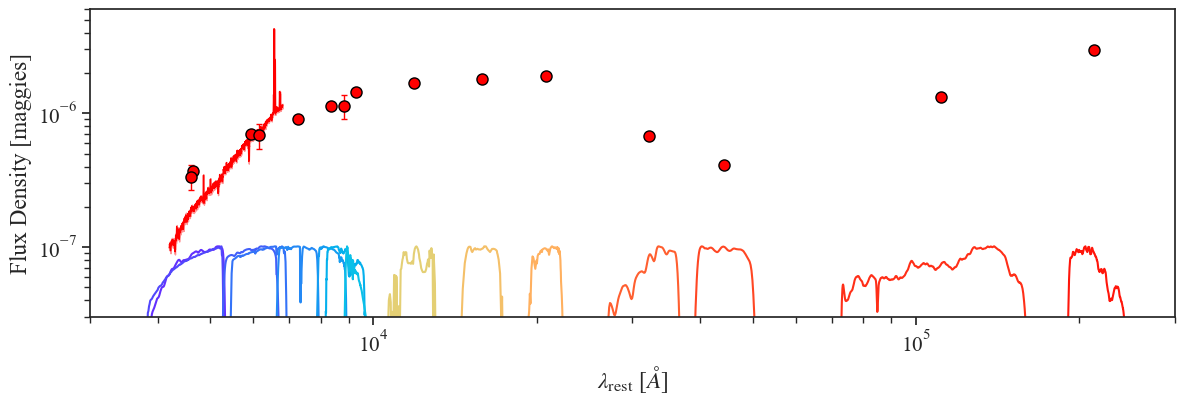

In [5]:
fig = plt.figure(figsize=(14, 4)); ax = plt.subplot()

xmin, xmax = 3000.0, 300000.0; ax.set_xlim(xmin, xmax)
ymin, ymax = 3e-08, 6e-06; ax.set_ylim(ymin, ymax)

ax.errorbar(obs['phot_wave'] / (1 + run_params["zred"]), obs['maggies'], yerr=obs['maggies_unc'],
             ecolor='red', fmt="o",  capsize=2,  elinewidth=1, markersize=8, markerfacecolor='red', markeredgecolor='black', markeredgewidth=1)
          
ax.plot(obs["wavelength"][obs["mask"]] / (1 + run_params["zred"]), obs['spectrum'][obs["mask"]],
         label='Observed Spectrum', alpha=1, linestyle='solid', lw=1, color='red')

ax.fill_between(obs["wavelength"][obs["mask"]] / (1 + run_params["zred"]),
                 obs['spectrum'][obs["mask"]] - obs["unc"][obs["mask"]], obs['spectrum'][obs["mask"]] + obs["unc"][obs["mask"]],
                 color="red", alpha=0.4)

# Plot transmission curves
for i in range(len(obs['filters'])):
    f = obs['filters'][i]
    w, t = f.wavelength.copy(), f.transmission.copy()
    t = t / t.max()
    t = 10**(0.23*(np.log10(ymax/ymin)))*t*ymin
    ax.plot(w/(1+run_params["zred"]), t, lw=1.5, color=cmap(color_idx[i]/len(filterset)), alpha=1)
    
# Labels and formatting
ax.set_yscale("log")
ax.set_xscale("log")
plt.xlabel(r'$\lambda_{\mathrm{rest}}$ [$\AA$]')
ax.set_ylabel('Flux Density [maggies]')



## The model object: build_model()

Now we need a set of model parameters, which will define the model we are tying to fit to the data. The model object stores the parameters that are used by the SPS object to build a spectrum, as well as infomation about which parameters are to be varied during fitting, and priors on those parameters. It efficiently converts between a vector of parameter values (the `theta` attribute) used by the MCMC samplers or optimizers and the dictionary of parameter names and values (the `params` attribute) that can be passed to the sps objects' `get_spectrum()` method.

To create the model object we need a list or dictionary of model parameters and some infomation about them. Each parameter must a have a `name`, a length `N` (vector parameters are possible), an initial value `init`, and must be specified as either a free parameter or a fixed parameter via an `isfree` key. If it is a free parameter it must have a prior specified as well, which we will get from the `priors` module. Please see the documentation for that module for details on the available priors.

Let's start by creating a dictionary that describes a single parameter controlling the stellar mass.


In [6]:
mass_param = {"name": "logmass",
              'N': 1, # The mass parameter here is a scalar, so it has N=1
              'isfree': True, # We will be fitting for the mass, so it is a free parameter
              'init': 10, # This is the initial value. For fixed parameters this is the value that will always be used. 
              'prior': priors.LogUniform(mini=6, maxi=12), # This sets the prior probability for the parameter
              'units': "solar masses formed",
              }


Ok, that's the description for one parameter. Let's build up the rest of our model as a dictionary of these parameter descriptions, keyed by parameter name. The type of model you build will depend on your data, the type of object you are looking at, and your scientific question. For this data, at a minimum we will need some sort of distance or redshift information, and something describing the SFH. We could also add parameters controlling metallicity, dust attenuation and emission, nebular emission, even the IMF. Note that any parameter whose value is not explicitly specified via a model parameter dictionary will be given the default value from `python-FSPS`.

While we could keep adding parameters by hand, the easiest way to build up this model is to start with some predefined parameter sets from the `prospect.models.templates` module, and then modify them to suit our needs. First, lets look at what pre-packaged parameter sets are available.

In [7]:
from prospect.models.templates import TemplateLibrary

# Look at all the prepackaged parameter sets
TemplateLibrary.show_contents()

'type_defaults':
  Explicitly sets dust amd IMF types.
'ssp':
  Basic set of (free) parameters for a delta function SFH
'parametric_sfh':
  Basic set of (free) parameters for a delay-tau SFH.
'dust_emission':
  The set of (fixed) dust emission parameters.
'nebular':
  The set of nebular emission parameters, with gas_logz tied to stellar logzsol.
'nebular_marginalization':
  Marginalize over emission amplitudes line contained inthe observed spectrum
'fit_eline_redshift':
  Fit for the redshift of the emission lines separatelyfrom the stellar redshift
'outlier_model':
  The set of outlier (mixture) models for spectroscopy and photometry
'agn':
  The set of (fixed) AGN dusty torus emission parameters.
'igm':
  The set of (fixed) IGM absorption parameters.
'spectral_smoothing':
  Set of parameters for spectal smoothing.
'optimize_speccal':
  Set of parameters (most of which are fixed) for optimizing a polynomial calibration vector.
'fit_speccal':
  Set of parameters (most of which are free

In [8]:
TemplateLibrary.describe("continuity_sfh")

Free Parameters: (name: prior) 
-----------
  logzsol: <class 'prospect.models.priors.TopHat'>(mini=-2,maxi=0.19)
  dust2: <class 'prospect.models.priors.TopHat'>(mini=0.0,maxi=2.0)
  logmass: <class 'prospect.models.priors.TopHat'>(mini=7,maxi=12)
  logsfr_ratios: <class 'prospect.models.priors.StudentT'>(mean=[0. 0.],scale=[0.3 0.3],df=[2 2])

Fixed Parameters: (name: value [, depends_on]) 
-----------
  zred: 0.1 
  mass: 1000000.0 <function logsfr_ratios_to_masses at 0x7fcb9b41a670>
  sfh: 3 
  imf_type: 2 
  dust_type: 0 
  agebins: [[0.0, 8.0], [8.0, 9.0], [9.0, 10.0]] 


That looks pretty good, this model has 5 free parameters:

* metallicity $\log Z/Z_\odot$
* stellar mass formed $\log M/M_\odot$
* dust attenuation optical depth for a foreground screen $A_V$
* ratios of star-formation rates in 3 consecutive bins $r_1, r_2$.

Everything else here is fixed explicitly (e.g. Chabrier IMF via `imf_type:2`). There are many other sps parameters that are set implicitly in the FSPS defaults. See the `python-FSPS` documentation for a complete list and details on the default values. Note that by default the stellar mass here refers to the stellar mass formed by the given age, which will always be slightly higher than the surviving stellar mass, due to mass loss during stellar evolution (winds, SNe, etc.)


## Spectral Energy Distribution Model Components
As mentioned above, the model parameters describe the stellar, nebular, active galactic nucleus (AGN), and dust components of the galaxy along with instrument parameters, and we specify the noise model and priors. Below, we list the model components used in this tutorial.

* **Flexible Stellar Population Synthesis code** (`PYTHON-FSPS`, [Conroy+2009](https://ui.adsabs.harvard.edu/abs/2009ApJ...699..486C), [Conroy+2010](https://ui.adsabs.harvard.edu/abs/2010ascl.soft10043C)) to compute the emergent galaxy spectrum by combining simple stellar populations, given a set of stellar population parameters. 

* **Non-parametric star-formation history model** which consists of a piece-wise constant SFH where the ratio of the average star-formation rate (SFR) in each lookback time bin is used to parameterize the stellar mass formed in that bin. This approach offers more flexibility in modeling the unusual shapes of SFHs that are not captured by parametric forms, thus reducing any biases that may exist from the strong prior of a particular parametric form of the SFH. Non-parametric models have been shown to be better suited to recover the shape of recent and older SFHs ([Johnson+2021](https://ui.adsabs.harvard.edu/abs/2021ApJS..254...22J)). This is important in inferring the stellar masses, mass-weighted stellar ages, recent SFRs, and delays from star-formation events. Hence, we choose to use non-parametric models in our work. We employ a continuity non-parametric SFH with seven bins and use the recommended StudentT prior on the SFR ratios. The SFRs in the two most recent bins (0-30 Myr and 30-100 Myr) are expected to be constrained by the nebular emission line features in the spectrum, the ultraviolet photometry and the infrared photometry (via dust emission), if available. The remaining five bins are spaced logarithmically uniform in time up to the age of the universe at the redshift of the galaxy.

* **Kroupa initial mass function** ([Kroupa+2001](https://ui.adsabs.harvard.edu/abs/2001MNRAS.322..231K)).
  
* **Mass-metallicity relation** of galaxies is enforced since a reliable measurement of stellar metallicity in the absence of high-quality absorption features in the spectrum can be tricky ([Gallazzi+2005](https://ui.adsabs.harvard.edu/abs/2005MNRAS.362...41G)). This prior also helps in breaking the age-metallicity degeneracy.

* **Dust attenuation effects** are included as a dust screen affecting stars of all ages, where the normalization of the wavelength dependence of the optical depth ([Kriek+2013](https://ui.adsabs.harvard.edu/abs/2013ApJ...775L..16K)) at 5500 Å, the extra attenuation towards young stars and the offset in slope from the dust attenuation curve ([Calzetti+2000](https://ui.adsabs.harvard.edu/abs/2000ApJ...533..682C)) are the free parameters. We also use the three-component dust emission model ([Draine+2007](https://ui.adsabs.harvard.edu/abs/2007ApJ...657..810D)) provided in FSPS where only the component describing the grain size distribution through the fraction of grain mass in polycyclic aromatic hydrocarbons (PAHs) is left as a free parameter. Since this grain model produces dust emission above 1 $\mu$m, we include it in our models only when data at these rest-frame wavelengths are available.

* **AGN dust torus emission component** is included in the model due to substantial mid-infrared emission and important implications of dust-obscured AGNs on the stellar ages and SFRs ([Nenkova+2008](https://ui.adsabs.harvard.edu/abs/2008ApJ...685..160N)). The inclusion of AGN templates smoothes out the derived SFH by removing the mis-identified dust emission around AGB stars in the 0.1-1 Gyr lookback time bins ([Leja+2018](https://ui.adsabs.harvard.edu/abs/2018ApJ...854...62L)).

* **Nebular emission model** in Prospector assumes that all the emission lines are powered by young stars, which may not be true in the presence of hard ionizing fields of AGNs or shock-heated emission. Hence, we marginalize over the amplitude of emission lines in our observed spectrum. We tie the gas-phase metallicity to the stellar metallicity and float the nebular ionization parameter. The nebular emission model 

* **Redshift** is initialized to the value obtained from pPXF fits with a uniform prior width of 1% to allow for a better fit to emission and absorption lines.

* **Calibration.** Due to systematics in measuring photometry and uncertainties in the underlying stellar and photoionization models, we assume additional 10% photometric errors as done in previous works ([Johnson+2021](https://ui.adsabs.harvard.edu/abs/2021ApJS..254...22J)). To avoid corrupting normalization-sensitive parameters by gross aperture corrections, we scale the spectrum to match the integrated photometry probed by the population and fit for a 12th-order Chebyshev polynomial as a multiplicative calibration function. We include spectral smoothing to account for the line-of-sight velocity distribution of stars and the instrumental resolution to better fit the emission lines and incorporate a pixel outlier model to marginalize over poorly modeled noise. We apply additional masking in the noisy parts of the spectrum.

To tailor this model to our data we'll want to just adjust a couple of the initial values and priors. We will do all this model building inside a method called `build_model`. This is useful because then we can control (at run-time) how the model is built via more meta-parameters. For example the redshift of the model can be specified, or we can decide to change a prior depending on which object the model is fitting. 

In [9]:
def build_model(**extras):
    """
    Returns
    -------
    model : SedModel or PolySedModel
        An instance of the spectral energy distribution model.
    """

    # Selecting the type of SFH model
    model_params = TemplateLibrary["continuity_sfh"] # Continuity SFH
    nbins = 7
    model_params["nbins_sfh"] = {'N': 1, 'isfree': False, 'init': nbins} # Number of age bins in SFH
    model_params['agebins']['N'] = nbins; model_params['agebins']['depends_on'] = zred_to_agebins
    model_params['mass']['N'] = nbins; model_params['mass']['depends_on'] = logmass_to_masses
    model_params['logsfr_ratios'] = {'N': nbins - 1, 'isfree': True, 'init': np.full(nbins - 1, 0.0),
                                     'prior': priors.StudentT(mean=np.full(nbins - 1, 0.0), scale=np.full(nbins - 1, 0.3), df=np.full(nbins - 1, 2))}
    # ------------------------------------------------------------------------------------------------------------------------------------------------
    
    # Spectroscopic redshift parameter
    model_params["zred"] = {'N': 1, 'isfree': True, 'units': "redshift", 
                            'init': extras["zred"], 'prior': priors.TopHat(mini=extras["zred"] - 0.01, maxi=extras["zred"] + 0.01)}
    # ------------------------------------------------------------------------------------------------------------------------------------------------
    
    # Metallicity and mass parameters using the mass-metallicity relation-based prior
    model_params['massmet'] = {'N': 2, 'isfree': True, 
                               'init': np.array([8.0, 0.0]), 'prior': MassMet(z_mini=-2.00, z_maxi=0.19, mass_mini=8, mass_maxi=12)}
    model_params['logmass'] = {'N': 1, 'isfree': False, 'depends_on': massmet_to_logmass, # Total stellar mass formed
                               'init': 10.0, 'units': 'Msun', 'prior': None}
    model_params['logzsol'] = {'N': 1, 'isfree': False, 'depends_on': massmet_to_logzsol, 'units': r'$\log (Z/Z_\odot)$', # Metallicity
                               'init': -0.5, 'prior': None}
    # ------------------------------------------------------------------------------------------------------------------------------------------------
    
    # Dust absorption parameters
    model_params['dust_type']['init'] = 4 # Kriek & Conroy dust attenuation curve
    model_params["dust2"]['prior'] = priors.ClippedNormal(mini=0.0, maxi=4.0, mean=0.3, sigma=1) # Dust attenuation of old stellar light
    model_params["dust_index"] = {'N': 1, 'isfree': True, 'units': "power-law multiplication of Calzetti", # Power law modification of Calzetti dust attenuation curve
                                  'init': 0.0, 'prior': priors.TopHat(mini=-1.0, maxi=0.4)}
    model_params['dust1'] = {'N': 1, 'isfree': False, 'depends_on': to_dust1, # Describes dust attenuation of young stellar light
                             'init': 0.0, 'units': "optical depth towards young stars", 'prior': None} 
    model_params['dust1_fraction'] = {'N': 1, 'isfree': True, 
                                      'init': 1.0, 'prior': priors.ClippedNormal(mini=0.0, maxi=2.0, mean=1.0, sigma=0.3)}
    # ------------------------------------------------------------------------------------------------------------------------------------------------
    
    # Smooth the spectrum based on resolution
    model_params.update(TemplateLibrary["spectral_smoothing"])
    model_params["sigma_smooth"] = {'prior': priors.TopHat(mini=50.0, maxi=500.0), # Velocity dispersion [km/s]
                                    'init': 200, 'isfree': True} 
    # ------------------------------------------------------------------------------------------------------------------------------------------------
    
    # Add dust emission parameters if specified
    model_params.update(TemplateLibrary["dust_emission"])
    model_params['duste_qpah']['isfree'] = True; model_params['duste_qpah']['prior'] = priors.TopHat(mini=0.5, maxi=7.0) # Describes grain size distribution of PAHs
    model_params['duste_gamma']['init'] = 0.01; model_params['duste_gamma']['isfree'] = False # Relative contribution of dust heated at and above Umin
    model_params['duste_umin']['isfree'] = False # Minimum dust emission radiation field strength
    # ------------------------------------------------------------------------------------------------------------------------------------------------

    # Add AGN parameters if specified
    model_params.update(TemplateLibrary["agn"])
    model_params['fagn']['isfree'] = True; model_params['fagn']['prior'] = priors.LogUniform(mini=1e-5, maxi=3.0) # Fraction of AGN luminosity relative to stellar bolometric luminosity
    model_params['agn_tau']['isfree'] = True; model_params['agn_tau']['prior'] = priors.LogUniform(mini=5.0, maxi=150.) # Optical depth of clouds in the AGN dust torus model
    # ------------------------------------------------------------------------------------------------------------------------------------------------

    # Add nebular emission parameters if specified
    model_params.update(TemplateLibrary["nebular"])
    model_params['gas_logu']['isfree'] = True # Nebular gas ionization parameter
    model_params['gas_logz']['isfree'] = True; _ = model_params["gas_logz"].pop("depends_on") # Gas-phase metallicity (Tied to the stellar metallicity)

    model_params.update(TemplateLibrary['nebular_marginalization'])
    model_params['nebemlineinspec']['init'] = True
    model_params['eline_prior_width'] = {'N': 1, 'isfree': True, 'init': 1,  # Width of emission line amplitude prior
                                         'units': r'width of Gaussian prior on line luminosity, in units of (true luminosity/FSPS predictions)',
                                         'prior': priors.TopHat(mini=0.01, maxi=100)}
    model_params['use_eline_prior']['init'] = True
    model_params["eline_sigma"] = {'N': 1, 'isfree': True, 'init': 200.0, 'units': r'km/s', 'prior': priors.TopHat(mini=30, maxi=500)} # Emission lines broadening
    # ------------------------------------------------------------------------------------------------------------------------------------------------
    
    # Calibration and outlier models
    model_params.update(TemplateLibrary['optimize_speccal'])
    model_params["polyorder"]['init'] = 12 #  Chebyshev polynomial order for spectrum calibration
    model_params['spec_norm']['isfree'] = False; model_params['spec_norm']['prior'] = priors.Normal(mean=1.0, sigma=0.3) # Spectrum normalization
    model_params['f_outlier_spec'] = {'N': 1, 'isfree': True, 'init': 0.01, 'prior': priors.TopHat(mini=1e-5, maxi=0.5)} # Fraction of outlier spectrum pixels 
    model_params['nsigma_outlier_spec'] = {'N': 1, 'isfree': False, 'init': 50.0} # Factor of inflation for errors determined by fspec_outlier
    model_params['f_outlier_phot'] = {'N': 1, 'isfree': False, 'init': 0.00, 'prior': priors.TopHat(mini=0, maxi=0.5)} # Fraction of outlier photometry measurements
    model_params['nsigma_outlier_phot'] = {'N': 1, 'isfree': False, 'init': 50.0} # Factor of inflation for errors determined by fphot_outlier
    model_params['spec_jitter'] = {'N': 1, 'isfree': True, 'init': 1.0, 'prior': priors.TopHat(mini=1.0, maxi=3.0)} # Spectral jitter parameter to inflate noise
    # ------------------------------------------------------------------------------------------------------------------------------------------------
    
    # Instantiate the model object
    return PolySedModel(model_params)


class MassMet(priors.Prior):
    """
    A Gaussian prior designed to approximate the Gallazzi et al. 2005 
    stellar mass--stellar metallicity relationship.
    """

    prior_params = ['mass_mini', 'mass_maxi', 'z_mini', 'z_maxi']
    distribution = truncnorm
    massmet = np.loadtxt('data/gallazzi_05_massmet.txt')

    def __len__(self):
        """ Hack to work with Prospector 0.3
        """
        return 2

    def scale(self, mass):
        """Calculate the scale parameter for the mass-metallicity relationship."""
        upper_84 = np.interp(mass, self.massmet[:, 0], self.massmet[:, 3])
        lower_16 = np.interp(mass, self.massmet[:, 0], self.massmet[:, 2])
        return upper_84 - lower_16

    def loc(self, mass):
        """Calculate the location parameter for the mass-metallicity relationship."""
        return np.interp(mass, self.massmet[:, 0], self.massmet[:, 1])

    def get_args(self, mass):
        """Calculate parameters 'a' and 'b' for the truncnorm distribution."""
        a = (self.params['z_mini'] - self.loc(mass)) / self.scale(mass)
        b = (self.params['z_maxi'] - self.loc(mass)) / self.scale(mass)
        return [a, b]

    @property
    def range(self):
        """Return the range of prior parameters."""
        return ((self.params['mass_mini'], self.params['mass_maxi']),
                (self.params['z_mini'], self.params['z_maxi']))

    def bounds(self, **kwargs):
        """Return the bounds of the prior parameters."""
        if len(kwargs) > 0:
            self.update(**kwargs)
        return self.range

    def __call__(self, x, **kwargs):
        """Compute the natural log of the prior probability at x."""
        if len(kwargs) > 0:
            self.update(**kwargs)
        p = np.atleast_2d(np.zeros_like(x))
        a, b = self.get_args(x[..., 0])
        p[..., 1] = self.distribution.pdf(x[..., 1], a, b, 
                                          loc=self.loc(x[..., 0]), 
                                          scale=self.scale(x[..., 0]))
        with np.errstate(invalid='ignore'):
            p[..., 1] = np.log(p[..., 1])
        return p

    def sample(self, nsample=None, **kwargs):
        """Draw samples from the prior distribution."""
        if len(kwargs) > 0:
            self.update(**kwargs)
        mass = np.random.uniform(low=self.params['mass_mini'], 
                                 high=self.params['mass_maxi'], size=nsample)
        a, b = self.get_args(mass)
        met = self.distribution.rvs(a, b, loc=self.loc(mass), 
                                    scale=self.scale(mass), size=nsample)
        return np.array([mass, met])

    def unit_transform(self, x, **kwargs):
        """Transform values from CDF to parameter space."""
        if len(kwargs) > 0:
            self.update(**kwargs)
        mass = x[0] * (self.params['mass_maxi'] - self.params['mass_mini']) + \
            self.params['mass_mini']
        a, b = self.get_args(mass)
        met = self.distribution.ppf(x[1], a, b, loc=self.loc(mass), 
                                    scale=self.scale(mass))
        return np.array([mass, met])


def to_dust1(dust1_fraction=None, 
             dust2=None, 
             **extras):
    """
    Returns:
    --------
    dust1          : float or None
        Computed dust1 value, or None if inputs are None.
    """
    return dust1_fraction * dust2


def zred_to_agebins(zred=None,
                    nbins_sfh=None,
                    **extras):
    """
    Returns:
    --------
    agebins   : numpy.ndarray
        Array of age bin edges.
    """
    tuniv = np.squeeze(cosmo.age(zred).to("yr").value)
    ncomp = np.squeeze(nbins_sfh)
    tbinmax = 0.9 * tuniv
    agelims = [0.0, 7.4772] + np.linspace(8.0, 
                                          np.log10(tbinmax), ncomp - 2).tolist(
                                          ) + [np.log10(tuniv)]
    agebins = np.array([agelims[:-1], agelims[1:]])
    return agebins.T



def logmass_to_masses(logmass=None,
                      logsfr_ratios=None,
                      zred=None,
                      **extras):
    """
    Returns:
    --------
    masses : numpy.ndarray
        Array of masses corresponding to each age bin.
    """
    agebins = zred_to_agebins(zred=zred, **extras)
    logsfr_ratios = np.clip(logsfr_ratios, -10, 10)
    nbins = agebins.shape[0]
    sratios = 10 ** logsfr_ratios
    dt = (10 ** agebins[:, 1] - 10 ** agebins[:, 0])
    coeffs = np.array([(1. / np.prod(sratios[:i])) *
                       (np.prod(dt[1:i+1]) / np.prod(dt[:i]))
                       for i in range(nbins)])
    m1 = (10 ** logmass) / coeffs.sum()
    return m1 * coeffs



def massmet_to_logmass(massmet=None, **extras):
    """
    Returns:
    --------
    logmass : float
        Logarithm of stellar mass.
    """
    return massmet[0]


def massmet_to_logzsol(massmet=None, **extras):
    """
    Returns:
    --------
    logzsol : float
        Logarithm of stellar metallicity (log Z/Z_sun).
    """
    return massmet[1]


def tie_gas_logz(logzsol=None, **extras): # Function to tie the gas metallicity to the stellar metallicity.
    """
    Returns:
    --------
    logzsol : float
        Logarithm of gas metallicity (log Z_gas/Z_sun).
    """
    return logzsol


In [10]:
model = build_model(**run_params)
print(model)
print("\nInitial free parameter vector theta:\n  {}\n".format(model.theta))
print("Initial parameter dictionary:\n{}".format(model.params))

:::::::
<class 'prospect.models.sedmodel.PolySedModel'>

Free Parameters: (name: prior) 
-----------
  zred: <class 'prospect.models.priors.TopHat'>(mini=0.026799999999999997,maxi=0.0468)
  dust2: <class 'prospect.models.priors.ClippedNormal'>(mean=0.3,sigma=1,mini=0.0,maxi=4.0)
  logsfr_ratios: <class 'prospect.models.priors.StudentT'>(mean=[0. 0. 0. 0. 0. 0.],scale=[0.3 0.3 0.3 0.3 0.3 0.3],df=[2 2 2 2 2 2])
  massmet: <class '__main__.MassMet'>(mass_mini=8,mass_maxi=12,z_mini=-2.0,z_maxi=0.19)
  dust_index: <class 'prospect.models.priors.TopHat'>(mini=-1.0,maxi=0.4)
  dust1_fraction: <class 'prospect.models.priors.ClippedNormal'>(mean=1.0,sigma=0.3,mini=0.0,maxi=2.0)
  sigma_smooth: <class 'prospect.models.priors.TopHat'>(mini=50.0,maxi=500.0)
  duste_qpah: <class 'prospect.models.priors.TopHat'>(mini=0.5,maxi=7.0)
  fagn: <class 'prospect.models.priors.LogUniform'>(mini=1e-05,maxi=3.0)
  agn_tau: <class 'prospect.models.priors.LogUniform'>(mini=5.0,maxi=150.0)
  gas_logz: <class 'p

## The source object: build_sps()

We are almost there, but we need an object that will build SEDs for a given set of parameters. In `Prospector` we call these sps objects. Given a dictionary of parameters (provided by the model object), they must be able to return a spectrum and photometry -- corresponding to the data in the `obs` dictionary -- and maybe some ancillary information. The generation of spectra and photometry is often done using large spectral libraries and, for galaxies, isochrone information. Typically in `Prospector` we use `fsps.StellarPopulation` objects, under thin wrappers that add a little functionality and change the API a bit. The different wrappers correspond to different SFH parameterizations. Here we use `prospect.sources.FastStepBasis` which works with non-parameteric SFH.

Again, it can be helpful to encapsulate the loading of the sps object in a `build_sps` method, with meta-parameters controlling the how the object is instantiated

In [11]:
def build_sps(**extras): # Build and return an SPS (Stellar Population Synthesis) object based on input parameters.
    """
    Returns:
    --------
    sps : object
        Instance of FastStepBasis for non-parametric models.
    """
    from prospect.sources import FastStepBasis
    sps = FastStepBasis(zcontinuous=1)
    return sps

sps = build_sps(**run_params)
help(sps.get_spectrum)

Help on method get_spectrum in module prospect.sources.ssp_basis:

get_spectrum(outwave=None, filters=None, peraa=False, **params) method of prospect.sources.ssp_basis.FastStepBasis instance
    Get a spectrum and SED for the given params.
    
    :param outwave: (default: None)
        Desired *vacuum* wavelengths.  Defaults to the values in
        ``sps.wavelength``.
    
    :param peraa: (default: False)
        If `True`, return the spectrum in erg/s/cm^2/AA instead of AB
        maggies.
    
    :param filters: (default: None)
        A list of filter objects for which you'd like photometry to be calculated.
    
    :param params:
        Optional keywords giving parameter values that will be used to
        generate the predicted spectrum.
    
    :returns spec:
        Observed frame spectrum in AB maggies, unless ``peraa=True`` in which
        case the units are erg/s/cm^2/AA.
    
    :returns phot:
        Observed frame photometry in AB maggies.
    
    :returns mass

## View the model
Now that we have the sps object we can also generate a prediction for the data from any set of model parameters. To see how this works, lets make an SED and plot it! This will use the initial parameter values for the model we built before.

Note that creating a new model with FSPS is somewhat time-intensive (of order seconds), but once the relevant SSPs have been built they are subsequently stored in cache so similar models can be generated much more quickly (of order milliseconds, unless you are changing parameters that affect the SSPs, like the IMF)

In [12]:
# Generate the model SED at the initial value of theta
theta = model.theta.copy()
initial_spec, initial_phot, initial_mfrac = model.sed(theta, obs=obs, sps=sps)


Initial guess for the model parameters: zred=0.0368,dust2=0.6,logsfr_ratios=0.0,massmet=8.0,dust_index=0.0,dust1_fraction=1.0,sigma_smooth=200.0,duste_qpah=4.0,fagn=0.0001,agn_tau=5.0,gas_logz=0.0,gas_logu=-2.0,eline_prior_width=1.0,eline_sigma=200.0,f_outlier_spec=0.01,spec_jitter=1.0


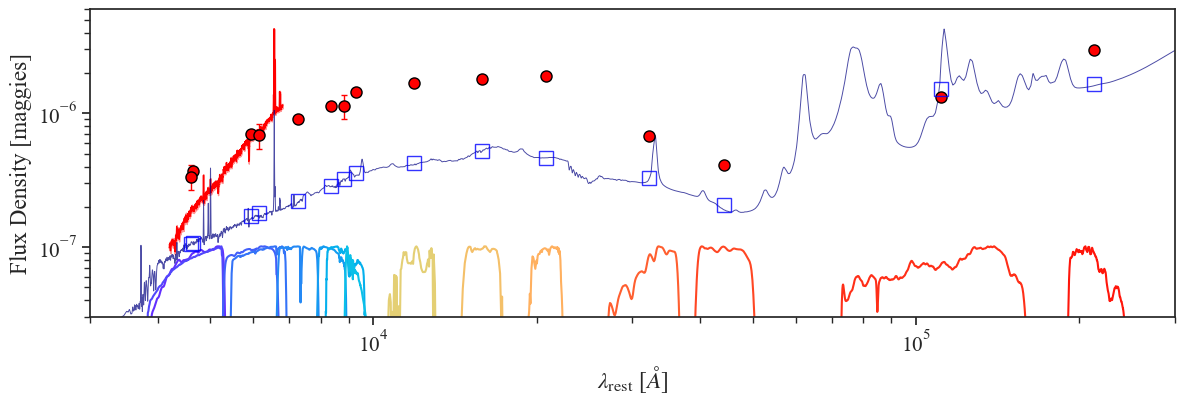

In [13]:
fig = plt.figure(figsize=(14, 4)); ax = plt.subplot()

ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)

# Plot observed data
ax.errorbar(obs['phot_wave'] / (1 + run_params["zred"]), obs['maggies'], yerr=obs['maggies_unc'], label='Observed Photometry',
            ecolor='red', fmt="o",  capsize=2,  elinewidth=1, markersize=8, markerfacecolor='red', markeredgecolor='black', markeredgewidth=1)

ax.plot(obs["wavelength"][obs["mask"]] / (1 + run_params["zred"]), obs['spectrum'][obs["mask"]],
         label='Observed Spectrum', alpha=1, linestyle='solid', lw=1, color='red')

ax.fill_between(obs["wavelength"][obs["mask"]] / (1 + run_params["zred"]),
                 obs['spectrum'][obs["mask"]] - obs["unc"][obs["mask"]], obs['spectrum'][obs["mask"]] + obs["unc"][obs["mask"]],
                 color="red", alpha=0.4)

# Plot initial guess model
ax.errorbar(obs["phot_wave"] / (1 + run_params["zred"]), initial_phot, yerr=None, label='Model Photometry', 
            marker='s', markersize=10, alpha=0.8, ls='', lw=2, markerfacecolor='none', markeredgecolor='blue', markeredgewidth=1)

ax.loglog(obs["wavelength"] / (1 + run_params["zred"]), initial_spec, label='Model Spectrum', lw=0.7, color='navy', alpha=0.7)

# Plot transmission curves
for i in range(len(obs['filters'])):
    f = obs['filters'][i]
    w, t = f.wavelength.copy(), f.transmission.copy()
    t = t / t.max()
    t = 10**(0.23*(np.log10(ymax/ymin)))*t*ymin
    ax.plot(w/(1+run_params["zred"]), t, lw=1.5, color=cmap(color_idx[i]/len(filterset)), alpha=1)
    
# Labels and formatting
ax.set_yscale("log")
ax.set_xscale("log")
plt.xlabel(r'$\lambda_{\mathrm{rest}}$ [$\AA$]')
ax.set_ylabel('Flux Density [maggies]')

text = ','.join(["{}={}".format(p, model.params[p][0]) for p in model.free_params])
print("Initial guess for the model parameters: {}".format(text))


## Likelihood function

Now all we are missing is a likelihood function. In most cases, this will simply be a function of the spectral likelihood and a photometric likelihood such that

\begin{equation}
\mathcal{L} = f(\mathcal{L}_\mathrm{phot}, \mathcal{L}_\mathrm{spec}).
\end{equation}

Assuming our errors are Normal (i.e. Gaussian), the log-likelihoods for each component are extremely straightforward to define and can be imported directly from prospector. How we choose to combine these likelihoods might vary depending on the particulars of our data. For the demo, our likelihood function for our model parameters is just

\begin{equation}
\log \mathcal{L} = \log \mathcal{L}_\mathrm{phot} + \log \mathcal{L}_\mathrm{spec}.
\end{equation}

Below is a simple version of the likelihood function used in `Prospector`. Note that more complicated likelihoods including covariant noise and fitted noise parameters are possible, using special `NoiseModel` classes within `Prospector`.

For nested sampling `lnprobfn(theta, nested=True)` will return the likelihood (since the prior probability is accounted for by drawing proposals from the priors), while for other types of MCMC sampling `lnprobfn(theta, nested=False)` returns the posterior probability.

In [14]:
from prospect.likelihood import lnlike_spec, lnlike_phot, write_log

verbose = False
def lnprobfn(theta, model=None, obs=None, sps=None, 
             nested=False, verbose=verbose):
    # Calculate prior probability and exit if not within prior
    # Also if doing nested sampling, do not include the basic priors, 
    # since the drawing method includes the prior probability
    lnp_prior = model.prior_product(theta, nested=nested)
    if not np.isfinite(lnp_prior):
        return -np.infty
        
    # Generate "mean" model
    spec, phot, mfrac = model.mean_model(theta, obs, sps=sps)
 
    # Calculate likelihoods
    lnp_spec = lnlike_spec(spec, obs=obs)
    lnp_phot = lnlike_phot(phot, obs=obs)

    return lnp_prior + lnp_phot + lnp_spec

run_params["verbose"] = verbose

However, `Prospector` comes with a pre-built `lnprobfn` that can incorporate more complex noise models, and can be either return ln-probability or chi-square or a vector of residuals depending on the algorithm being used. So let's use that!

In [15]:
from prospect.fitting import lnprobfn
print(help(lnprobfn))


Help on function lnprobfn in module prospect.fitting.fitting:

lnprobfn(theta, model=None, obs=None, sps=None, noise=(None, None), residuals=False, nested=False, verbose=False)
    Given a parameter vector and optionally a dictionary of observational
    ata and a model object, return the matural log of the posterior. This
    requires that an sps object (and if using spectra and gaussian processes, a
    NoiseModel) be instantiated.
    
    :param theta:
        Input parameter vector, ndarray of shape (ndim,)
    
    :param model:
        SedModel model object, with attributes including ``params``, a
        dictionary of model parameter state.  It must also have
        :py:func:`prior_product`, and :py:func:`predict` methods
        defined.
    
    :param obs:
        A dictionary of observational data.  The keys should be
    
        + ``"wavelength"``  (angstroms)
        + ``"spectrum"``    (maggies)
        + ``"unc"``         (maggies)
        + ``"maggies"``     (photome

## Running Prospector
Now that we have defined the model and set up the data that we want to fit, we are ready to run prospector. 

In [16]:
from prospect.fitting import fit_model
help(fit_model)


Help on function fit_model in module prospect.fitting.fitting:

fit_model(obs, model, sps, noise=(None, None), lnprobfn=<function lnprobfn at 0x7fcb9b587af0>, optimize=False, emcee=False, dynesty=True, **kwargs)
    Fit a model to observations using a number of different methods
    
    :param obs:
        The ``obs`` dictionary containing the data to fit to, which will be
        passed to ``lnprobfn``.
    
    :param model:
        An instance of the :py:class:`prospect.models.SedModel` class
        containing the model parameterization and parameter state.  It will be
        passed to ``lnprobfn``.
    
    :param sps:
        An instance of a :py:class:`prospect.sources.SSPBasis` (sub-)class.
        Alternatively, anything with a compatible :py:func:`get_spectrum` can
        be used here. It will be passed to ``lnprobfn``
    
    :param noise: (optional, default: (None, None))
        A tuple of NoiseModel objects for the spectroscopy and photometry
        respectively.  Ca

Note in particular that the output is a dictionary with both optimization and sampling entries. This is because one can do both within a single call to `fit_model`, and for ensemble sampling in particular it can be useful to do optimization first to get close to the data before beginnning the sampling.

## Minimization

We can attempt to initialize our model reasonably close to the data by using some numerical minimization routines, for example, Levenberg-Marquardt. **We will skip minimization in this tutorial because we use Dynamic Nested Sampling routine `dynesty`, which does not benefit from minimization.**


In [17]:
# # --- start minimization ----
# run_params["dynesty"] = False
# run_params["emcee"] = False
# run_params["optimize"] = True
# run_params["min_method"] = 'lm'
# # We'll start minimization from "nmin" separate places, the first based on the current values of each parameter and the 
# # rest drawn from the prior.  Starting from these extra draws can guard against local minima, or problems caused by 
# # starting at the edge of a prior (e.g. dust2=0.0)
# run_params["nmin"] = 64

# output = fit_model(obs, model, sps, lnprobfn=lnprobfn, **run_params)
# print("Done optmization in {}s".format(output["optimization"][1]))


Now let's see how our model looks in the data space after minimization. The model should already be set to the result of the best optimization, but we can also find the best run and set the model parameters to that result by hand.


In [18]:
# (results, topt) = output["optimization"]

# # Find which of the minimizations gave the best result and use the parameter vector for that minimization
# ind_best = np.argmin([r.cost for r in results])
# theta_best = results[ind_best].x.copy()
# print(theta_best)
# text = ','.join(["{}={}".format(p, model.params[p]) for p in model.free_params])
# print(title_text)
# # generate model
# pspec, pphot, pfrac = model.mean_model(theta_best, obs=obs, sps=sps)


In [19]:
# fig = plt.figure(figsize=(14, 4)); ax = plt.subplot()

# ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)

# # Plot observed data
# ax.errorbar(obs['phot_wave'] / (1 + run_params["zred"]), obs['maggies'], yerr=obs['maggies_unc'], label='Observed Photometry',
#             ecolor='red', fmt="o",  capsize=2,  elinewidth=1, markersize=8, markerfacecolor='red', markeredgecolor='black', markeredgewidth=1)

# ax.plot(obs["wavelength"][obs["mask"]] / (1 + run_params["zred"]), obs['spectrum'][obs["mask"]] / np.interp(obs["wavelength"][obs["mask"]], obs["wavelength"], model._speccal),
#         label='Observed Spectrum', alpha=1, linestyle='solid', lw=1, color='red')

# ax.fill_between(obs["wavelength"][obs["mask"]] / (1 + run_params["zred"]),
#                 (obs['spectrum'][obs["mask"]] / np.interp(obs["wavelength"][obs["mask"]], obs["wavelength"], model._speccal) - obs["unc"][obs["mask"]]),
#                 (obs['spectrum'][obs["mask"]] / np.interp(obs["wavelength"][obs["mask"]], obs["wavelength"], model._speccal) + obs["unc"][obs["mask"]]),
#                 color="red", alpha=0.4)

# # Plot minimized model
# ax.errorbar(obs["phot_wave"] / (1 + run_params["zred"]), pphot, yerr=None, label='Model Photometry', 
#             marker='s', markersize=10, alpha=0.8, ls='', lw=2, markerfacecolor='none', markeredgecolor='blue', markeredgewidth=1)

# ax.loglog(obs["wavelength"] / (1 + run_params["zred"]), pspec/model._speccal, label='Model Spectrum', lw=0.7, color='navy', alpha=0.7)

# # Plot transmission curves
# for i in range(len(obs['filters'])):
#     f = obs['filters'][i]
#     w, t = f.wavelength.copy(), f.transmission.copy()
#     t = t / t.max()
#     t = 10**(0.23*(np.log10(ymax/ymin)))*t*ymin
#     ax.plot(w/(1+run_params["zred"]), t, lw=1.5, color=cmap(color_idx[i]/len(filterset)), alpha=1)
    
# # Labels and formatting
# ax.set_yscale("log")
# ax.set_xscale("log")
# ax.set_xlabel(r'$\lambda_{\mathrm{rest}}$ [$\AA$]')
# ax.set_ylabel('Flux Density [maggies]')

# text = ','.join(["{}={}".format(p, model.params[p][0]) for p in model.free_params])
# print("Initial guess for the model parameters: {}".format(text))


## Sampling the Posterior: Nested sampling

Instead of ensemble MCMC sampling we can sample using dynamic nested sampling via `dynesty`. Dynamic nested sampling works by sampling from within successive iso-likelihood contours, transforming a distribution of live points from the prior to the posterior. It does not benefit from burn-in via optimization.

There are a number of parameters that control the operation of dynesty. A listing and brief description of each is given in the default prospector arguments (see below), here we will set just a few of the most important ones.


In [20]:
# add in dynesty settings
run_params["optimize"] = False
run_params["emcee"] = False
run_params["dynesty"] = True
run_params['nested_weight_kwargs'] = {'pfrac': 1.0}
run_params['nested_nlive_batch'] = 200 # 500
run_params['nested_walks'] = 48  # sampling gets very inefficient w/ high S/N spectra
run_params['nested_nlive_init'] = 400 # 500 
run_params['nested_dlogz_init'] = 0.05
run_params['nested_maxcall'] = 7500000
run_params['nested_maxcall_init'] = 7500000
run_params['nested_sample'] = 'rwalk'
run_params['nested_maxbatch'] = None
run_params['nested_posterior_thresh'] = 0.05 # 0.03
run_params['nested_first_update'] = {'min_ncall': 20000, 'min_eff': 7.5}
run_params['nested_target_n_effective'] = 1000

from functools import partial
lnprobfn_fixed = partial(lnprobfn, sps=sps)

# Run dynesty
# output = fit_model(obs, model, sps, lnprobfn=lnprobfn_fixed, **run_params)
# print('done dynesty in {0}s'.format(output["sampling"][1]))

outfile = "data/mizu.h5"
# writer.write_hdf5(outfile, run_params, model,
#                   {"maggies": obs["maggies"]}, output["sampling"][0], None, 
#                   tsample=output["sampling"][1], toptimize=output["optimization"][1]) 
result, _, _ = reader.results_from(outfile, dangerous=False)


In [21]:
weights = result.get('weights', None)

imax = np.argmax(result['lnprobability'])
theta_max = result["chain"][imax, :]
print('MAP value: {}'.format(theta_max))


MAP value: [ 3.60937317e-02  6.51926256e-01  3.93229118e-01 -2.07799063e-01
  2.18831959e-02 -3.04587408e-01 -6.92626618e-01  1.33763439e-01
  1.06342565e+01 -1.12532777e+00 -8.89044763e-01  7.87056909e-01
  1.28705952e+02  6.62607742e-01  1.60782093e-02  1.01785215e+02
  3.60422447e-01 -3.00361620e+00  8.91381630e+01  3.17194483e+02
  4.99966235e-01  1.21962056e+00]


## Visualizing the highest posterior probability model

In [22]:
pspec_map, pphot_map, pfrac_map = model.mean_model(theta_max, obs=obs, sps=sps)

(-10.0, 10.0)

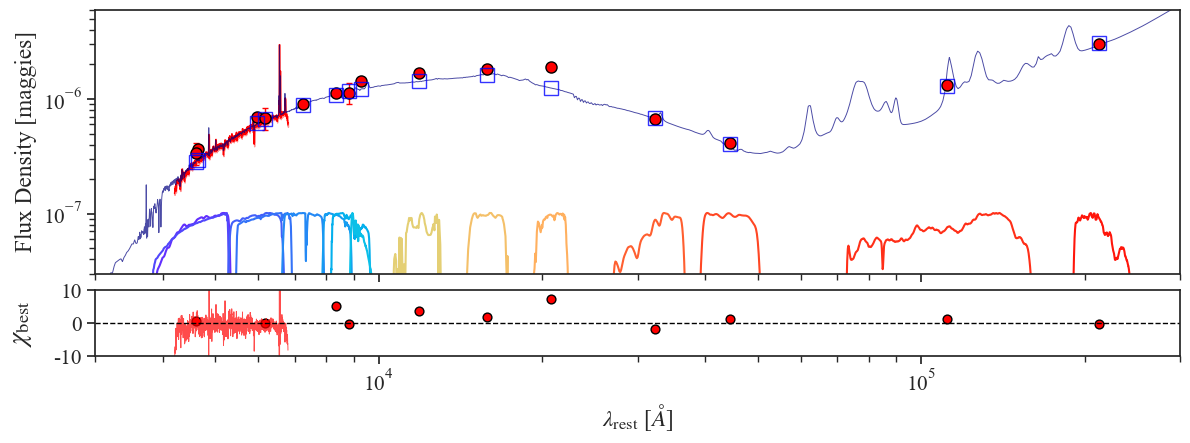

In [23]:
pspec_map, pphot_map, pfrac_map = model.mean_model(theta_max, obs=obs, sps=sps)
fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(14, 4.5), sharex=True, gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.1})

ax1.set_xlim(xmin, xmax); ax1.set_ylim(ymin, ymax)

# Plot observed data
ax1.errorbar(obs['phot_wave'] / (1 + run_params["zred"]), obs['maggies'], yerr=obs['maggies_unc'], label='Observed Photometry',
            ecolor='red', fmt="o",  capsize=2,  elinewidth=1, markersize=8, markerfacecolor='red', markeredgecolor='black', markeredgewidth=1)

ax1.plot(obs["wavelength"][obs["mask"]] / (1 + run_params["zred"]), obs['spectrum'][obs["mask"]]/ model._speccal[obs["mask"]],
        label='Observed Spectrum', alpha=1, linestyle='solid', lw=1, color='red')

ax1.fill_between(obs["wavelength"][obs["mask"]] / (1 + run_params["zred"]),
                (obs['spectrum'][obs["mask"]] / np.interp(obs["wavelength"][obs["mask"]], obs["wavelength"], model._speccal) - obs["unc"][obs["mask"]]),
                (obs['spectrum'][obs["mask"]] / np.interp(obs["wavelength"][obs["mask"]], obs["wavelength"], model._speccal) + obs["unc"][obs["mask"]]),
                color="red", alpha=0.4)

# Plot model
ax1.errorbar(obs["phot_wave"] / (1 + run_params["zred"]), pphot_map, yerr=None, label='Model Photometry', 
            marker='s', markersize=10, alpha=0.8, ls='', lw=2, markerfacecolor='none', markeredgecolor='blue', markeredgewidth=1)

ax1.loglog(obs["wavelength"] / (1 + run_params["zred"]), pspec_map/model._speccal, label='Model Spectrum', lw=0.7, color='navy', alpha=0.7)

# Plot transmission curves
for i in range(len(obs['filters'])):
    f = obs['filters'][i]
    w, t = f.wavelength.copy(), f.transmission.copy()
    t = t / t.max()
    t = 10**(0.23*(np.log10(ymax/ymin)))*t*ymin
    ax1.plot(w/(1+run_params["zred"]), t, lw=1.5, color=cmap(color_idx[i]/len(filterset)), alpha=1)
    
# Labels and formatting
ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_xlabel(r'$\lambda_{\mathrm{rest}}$ [$\AA$]')
ax1.set_ylabel('Flux Density [maggies]')

# Plot residual spectrum
ax2.plot(obs["wavelength"][obs["mask"]] / (1 + run_params["zred"]),
         -((pspec_map[obs["mask"]] / model._speccal[obs["mask"]]) - (obs['spectrum'][obs["mask"]] / np.interp(obs["wavelength"][obs["mask"]], obs["wavelength"], model._speccal))) / (obs["unc"][obs["mask"]]),
         lw=0.7, color='red', alpha=0.7)

# Plot residual photometry
ax2.scatter(obs['phot_wave'] / (1 + run_params["zred"]),
            -(pphot_map - obs['maggies']) / obs['maggies_unc'],
            marker='o', s=40, edgecolors="black", color="red")

# Axis labels and formatting
ax2.set_xlabel(r'$\lambda_{\mathrm{rest}}$ [$\AA$]')
ax2.set_ylabel(r'$\chi_{\mathrm{best}}$', labelpad=14, fontsize=19)
ax2.axhline(0, linestyle="--", color="black", linewidth=1)
ax2.set_ylim([-10, 10])


Lets zoom in on the spectrum and check the quality of our fits.

(1e-07, 4e-06)

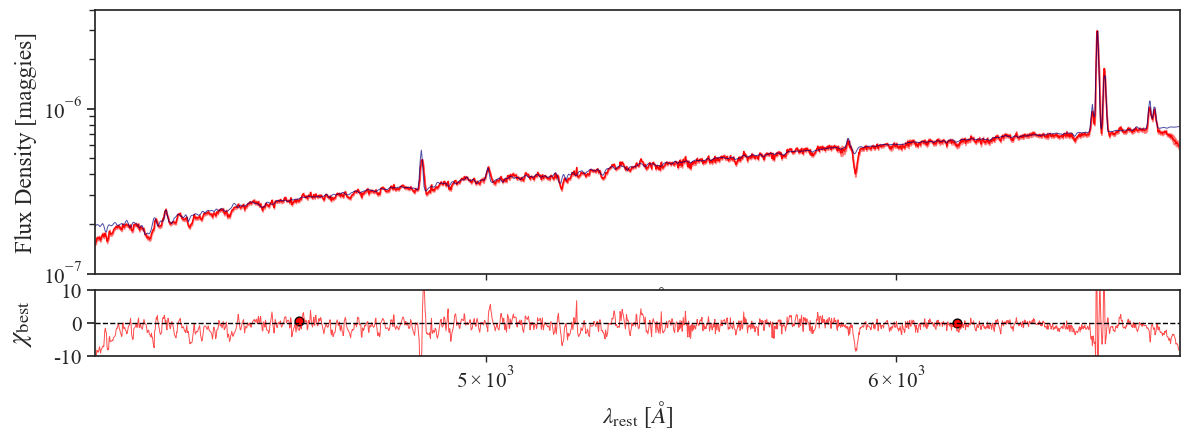

In [24]:
fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(14, 4.5), sharex=True, gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.1})

# Plot observed data
ax1.plot(obs["wavelength"][obs["mask"]] / (1 + run_params["zred"]), obs['spectrum'][obs["mask"]] / np.interp(obs["wavelength"][obs["mask"]], obs["wavelength"], model._speccal),
        label='Observed Spectrum', alpha=1, linestyle='solid', lw=1, color='red')

ax1.fill_between(obs["wavelength"][obs["mask"]] / (1 + run_params["zred"]),
                (obs['spectrum'][obs["mask"]] / np.interp(obs["wavelength"][obs["mask"]], obs["wavelength"], model._speccal) - obs["unc"][obs["mask"]]),
                (obs['spectrum'][obs["mask"]] / np.interp(obs["wavelength"][obs["mask"]], obs["wavelength"], model._speccal) + obs["unc"][obs["mask"]]),
                color="red", alpha=0.4)

# Plot model
ax1.loglog(obs["wavelength"] / (1 + run_params["zred"]), pspec_map/model._speccal, label='Model Spectrum', lw=0.7, color='navy', alpha=0.7)
    
# Labels and formatting
ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_xlabel(r'$\lambda_{\mathrm{rest}}$ [$\AA$]')
ax1.set_ylabel('Flux Density [maggies]')

# Plot residual spectrum
ax2.plot(obs["wavelength"][obs["mask"]] / (1 + run_params["zred"]),
         -((pspec_map[obs["mask"]] / model._speccal[obs["mask"]]) - (obs['spectrum'][obs["mask"]] / np.interp(obs["wavelength"][obs["mask"]], obs["wavelength"], model._speccal))) / (obs["unc"][obs["mask"]]),
         lw=0.7, color='red', alpha=0.7)

# Plot residual photometry
ax2.scatter(obs['phot_wave'] / (1 + run_params["zred"]),
            -(pphot_map - obs['maggies']) / obs['maggies_unc'],
            marker='o', s=40, edgecolors="black", color="red")

# Axis labels and formatting
ax2.set_xlabel(r'$\lambda_{\mathrm{rest}}$ [$\AA$]')
ax2.set_ylabel(r'$\chi_{\mathrm{best}}$', labelpad=14, fontsize=19)
ax2.axhline(0, linestyle="--", color="black", linewidth=1)
ax2.set_ylim([-10, 10])

ax1.set_xlim([np.min(obs["wavelength"][obs["mask"]]) / (1 + theta_max[0]),
              np.max(obs["wavelength"][obs["mask"]]) / (1 + theta_max[0])])
ax1.set_ylim(1e-7, 4e-6)


## Best-Fit Galaxy Star-Formation History

(13.2631820430805, 0.01)

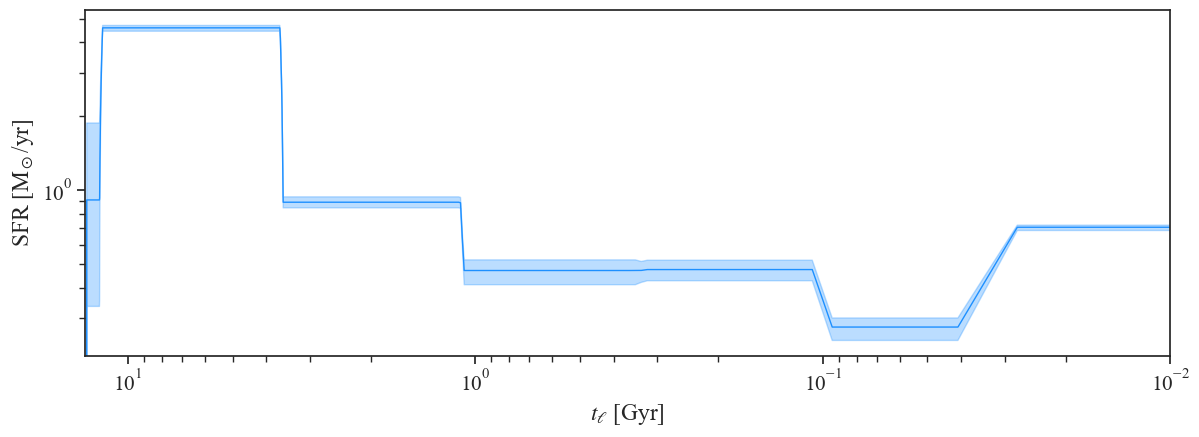

In [25]:
# Import necessary libraries
params = model.params
from prospect.plotting.corner import quantile

# Set up the plot figure
plt.figure(figsize=(14, 4.5))
grid = plt.GridSpec(30, 10, wspace=0.5, hspace=20)
ax1 = plt.subplot(grid[:, :])

# Calculate lookback times and set up for SFH calculation
lookback_times = 10**(model.params["agebins"] - 9)
sfrs = []

# Compute SFRs from model chain results
for i in range(len(result["chain"])):
    sfrs.append(ratios_to_sfrs(result["chain"][i][8], 
                               result["chain"][i][2:2+7-1], 
                               agebins=model.params["agebins"]))
sfrs = np.array(sfrs)

ns = sfrs.shape[0]
tvec = np.linspace(1e-3, lookback_times[-1][-1], 1000)
eps = 0.01
tlook = 10**model.params["agebins"] / 1e9 * np.array([1. + eps, 1. - eps])
tlook = np.tile(tlook, (ns, 1, 1))
tt = tlook.reshape(tlook.shape[0], -1)
ss = np.array([sfrs, sfrs]).transpose(1, 2, 0).reshape(tlook.shape[0], -1)

# Compute SFH by interpolating SFRs over time
sfhs = np.array([np.interp(tvec, t, s, left=0, right=0) for t, s in zip(tt, ss)])
weights = result.get('weights', None)

# Compute quantiles and plot SFH
sq = quantile(sfhs.T, q=[0.16, 0.50, 0.84], weights=weights)
ax1.plot(tvec, sq[:, 1], lw=1, color='dodgerblue', label="50th Percentile Sample")
ax1.fill_between(tvec, sq[:, 0], sq[:, 2], color='dodgerblue', alpha=0.3)

# Set plot labels and scaling
ax1.set_xlabel(r"$t_{\ell}$ [Gyr]")
ax1.set_ylabel(r"SFR [M$_\odot$/yr]")
ax1.set_xscale("log")
ax1.set_yscale("log")
t_gal = cosmo.age(run_params["zred"] * cu.redshift).value
ax1.set_xlim(t_gal, 1e-2)



That's a rejuvenating galaxy!

## Cornerplot of Model Parameters

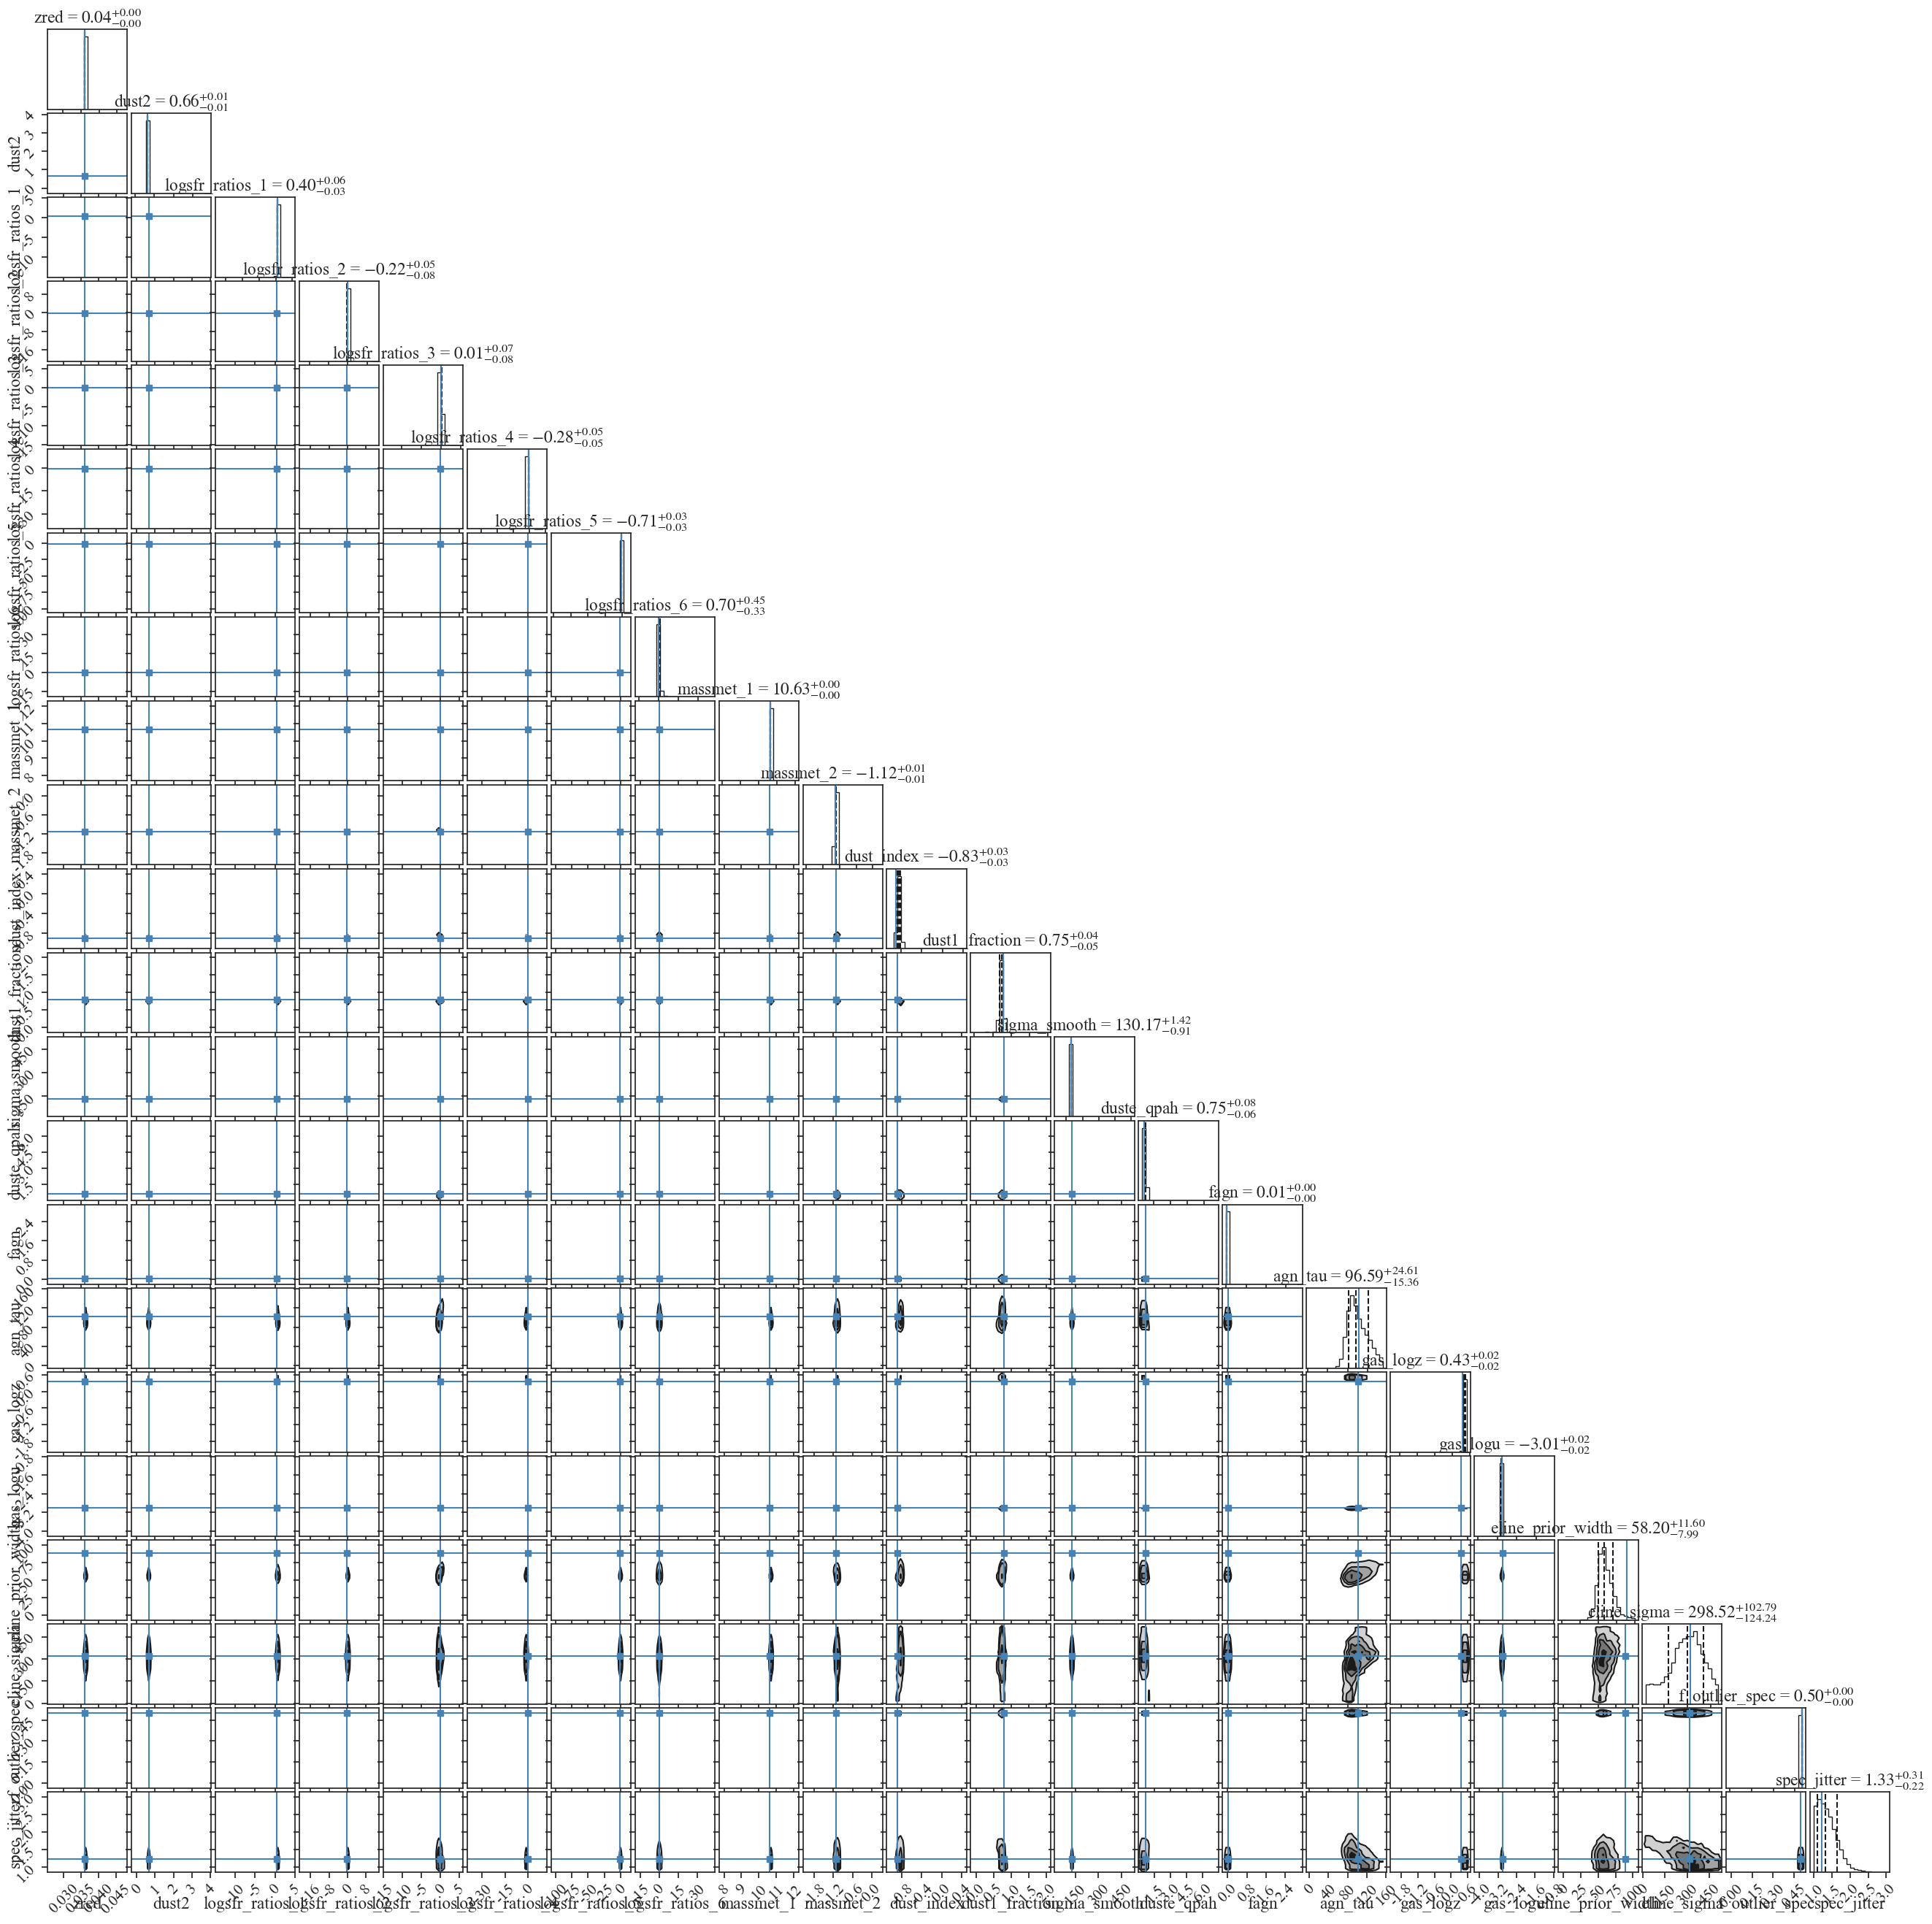

In [26]:
cornerfig = reader.subcorner(result, start=0, thin=1, truths=theta_max, 
                            fig=subplots(len(model.free_params)+5+1,
                                         len(model.free_params)+5+1,
                                         figsize=(26, 26))[0])


In [27]:
def compute_quantile(x, q, weights=None): # Compute quantiles of a dataset x, with optional weights. 
    # Convert q to percentiles
    percentiles = np.array(q) * 100.0

    if weights is None:
        return np.percentile(x, percentiles)
    else:
        idx = np.argsort(x)
        xsorted = x[idx]
        sorted_weights = weights[idx]
        cdf = np.cumsum(sorted_weights)
        cdf /= cdf[-1]
        return np.interp(q, cdf, xsorted).tolist()

def print_quantiles(arr, arr_wts):
    quant50 = round(compute_quantile(arr, [0.5], arr_wts)[0], 4)
    err_l = round(compute_quantile(arr, [0.16], arr_wts)[0] - compute_quantile(arr, [0.5], arr_wts)[0], 4)
    err_u = round(compute_quantile(arr, [0.84], arr_wts)[0] - compute_quantile(arr, [0.5], arr_wts)[0], 4)
    print(r"${}_{}^{}$".format(quant50, err_l, err_u))
    


In [28]:
Mstars = []; Mstars_wts = []
for i in tqdm(range(100)):
    j = np.random.randint(len(result["chain"]))
    theta = result['chain'][j]
    mspec, mphot, mextra = model.mean_model(theta, obs, sps=sps)
    Mstars.append(np.log10(10**(theta[8])*mextra)) # computing the current stellar mass by multiplying it with the surviving mass fraction
    Mstars_wts.append(weights[j])
Mstars = np.array(Mstars); Mstars_wts = np.array(Mstars_wts)

print(r"$\log M/M_\odot$")
print_quantiles(Mstars, Mstars_wts)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:26<00:00,  1.16it/s]

$\log M/M_\odot$
$10.3994_-0.0022^0.003$


In [29]:
sfr_20Myr = []; sfr_100Myr = []; ssfrs = []
params = model.params

for i in tqdm(range(len(result["chain"]))):
    sfr = nonpar_recent_sfr(np.array([result["chain"][i, 8]]), np.array([result["chain"][i, 2:2+7-1]]), np.array(params["agebins"]), sfr_period=0.02)
    sfr_20Myr.append(sfr)
    
    sfr = nonpar_recent_sfr(np.array([result["chain"][i, 8]]), np.array([result["chain"][i, 2:2+7-1]]), np.array(params["agebins"]))
    sfr_100Myr.append(sfr)
    
    mass = result["chain"][i, 8]
    ssfr = sfr*1e9/(10**mass)
    ssfrs.append(ssfr)

sfr_20Myr = np.array(sfr_20Myr)[:, 0]
sfr_100Myr = np.array(sfr_100Myr)[:, 0]
ssfrs = np.array(ssfrs)[:, 0]

print(r"SFR$\mathrm{20 Myr}$")
print_quantiles(sfr_20Myr, weights)

print(r"SFR$\mathrm{100 Myr}$")
print_quantiles(sfr_100Myr, weights)

print(r"sSFR$\mathrm{100 Myr}$")
print_quantiles(ssfrs, weights)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39810/39810 [00:10<00:00, 3677.18it/s]


SFR$\mathrm{20 Myr}$
$0.7103_-0.0213^0.0141$
SFR$\mathrm{100 Myr}$
$0.4068_-0.0253^0.0191$
sSFR$\mathrm{100 Myr}$
$0.0096_-0.0006^0.0005$


In [30]:
dust1 = []; logzsol = []

for i in tqdm(range(len(result["chain"]))):
    dust1.append(result["chain"][i, 6+np.where(np.array(model.free_params) == "dust1_fraction")[0][0]]*result["chain"][i, np.where(np.array(model.free_params) == "dust2")[0][0]])
    logzsol.append(result["chain"][i, 9])
    
dust1 = np.array(dust1)
logzsol = np.array(logzsol)
    
print(r"A$\mathrm{V,young}$")
print_quantiles(dust1, weights)

print(r"$\log Z/Z_\odot$")
print_quantiles(logzsol, weights)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39810/39810 [00:00<00:00, 51720.65it/s]


A$\mathrm{V,young}$
$0.4952_-0.0355^0.0218$
$\log Z/Z_\odot$
$-1.1168_-0.008^0.0077$


In [31]:
for param in model.free_params:
    if param in ["logsfr_ratios", 'eline_prior_width', 'eline_sigma', 'massmet',
                 'sigma_smooth', 'gas_logz', 'f_outlier_spec', 'spec_jitter']:
        continue
    elif param in ['zred', 'dust2']:
        param_model = []
        for i in range(len(result["chain"])):
            param_model.append(result["chain"][i, np.where(np.array(model.free_params) == param)[0][0]])
        print(param)
        print_quantiles(np.array(param_model), weights)
    else:
        param_model = []
        for i in range(len(result["chain"])):
            param_model.append(result["chain"][i, 6+np.where(np.array(model.free_params) == param)[0][0]])
        print(param)
        print_quantiles(np.array(param_model), weights)


zred
$0.0361_-0.0^0.0$
dust2
$0.6595_-0.0063^0.0062$
dust_index
$-0.831_-0.0299^0.0282$
dust1_fraction
$0.7501_-0.0549^0.0368$
duste_qpah
$0.7473_-0.0644^0.0765$
fagn
$0.014_-0.0017^0.0017$
agn_tau
$96.5896_-15.3659^24.6194$
gas_logu
$-3.0118_-0.0212^0.0181$


In [32]:
sfrs = []; masses = []
for i in range(len(result["chain"])):
    sfrs.append(ratios_to_sfrs(result["chain"][i][8], result["chain"][i][2:2+7-1], agebins=model.params["agebins"]))
    masses.append(result["chain"][i][8])
sfrs = np.array(sfrs)
masses = np.array(masses)

lookback_times = 10**(model.params["agebins"]-9)
tbins = (lookback_times[:, 1] - lookback_times[:, 0]) * 1e9
tbins_age = ((lookback_times[:, 0] + lookback_times[:, 1]) / 2) * 1e9

tms = np.array([(sum(sfrs[i, :]*((tbins)*tbins_age))/(10**masses[i])) for i in range(np.shape(sfrs)[0])])/1e9 # Gyr
print(r'$t_m$[Gyr]')
print_quantiles(np.array(tms), weights)



$t_m$[Gyr]
$7.4967_-0.0749^0.1426$


## Mass-Metallicity Relation

The mass–metallicity relation (MZR; [Gallazzi+2005](https://ui.adsabs.harvard.edu/abs/2005MNRAS.362...41G/abstract)) is an empirical correlation observed in galaxies, showing that more massive galaxies tend to have higher metallicities (i.e., higher abundance of elements heavier than helium). This trend reflects the balance between gas inflows, star formation, and feedback-driven outflows: massive galaxies can retain their enriched gas more effectively due to deeper gravitational potentials, while low-mass galaxies lose a larger fraction of metals through winds. The MZR is a key tool in galaxy evolution studies, linking stellar mass growth to the chemical enrichment history of galaxies.

Since we used a mass-metallicity relation-based prior in our spectral energy distribution inference, we naively expect our measurements for FRB Mizu to be consistent with the mass–metallicity relation. Below, lets visualize our FRBs against the background galaxy population. 

With the ultimate goal of avoiding any systematics from the differences in stellar population modeling techniques for our FRBs and the background galaxy population, we use galaxy population data products presented in [Leja+2020](https://ui.adsabs.harvard.edu/abs/2020ApJ...893..111L/abstract) and [Leja+2022](https://ui.adsabs.harvard.edu/abs/2022ApJ...936..165L/abstract). These data products were derived using the properties of galaxies in the COSMOS-2015 ([Laigle+2016](https://ui.adsabs.harvard.edu/abs/2016ApJS..224...24L)) and 3D-HST ([Skelton+2014](https://ui.adsabs.harvard.edu/abs/2014ApJS..214...24S)) galaxy catalogs, inferred using similar `Prospector`-based procedures as ours, including a seven-component SFH, a two-component flexible dust attenuation model, nebular emission, and AGN-heated dust-torus emission ([Leja+2019](https://ui.adsabs.harvard.edu/abs/2019ApJ...877..140L), [Leja+2020](https://ui.adsabs.harvard.edu/abs/2020ApJ...893..111L/abstract), [Leja+2022](https://ui.adsabs.harvard.edu/abs/2022ApJ...936..165L/abstract)). The 3D-HST photometric catalog comprises of $\sim23,000$ galaxies from $\sim900$ arcmin$^2$ field of view at redshifts $z \in [0.5, 1]$ with rest-frame photometry in the range 0.3-8 $\mu$m and spectroscopic/grism redshifts for 30\% of the objects. The COSMOS-2015 photometric catalog comprises of $\sim48,500$ galaxies from 2 deg$^2$ COSMOS field at redshifts $z \in [0.005, 0.8]$ with photometry covering rest-frame 0.2-24 $\mu$m and photometric redshifts for a majority of objects. 


In [33]:
def read_cosmos_data(apply_cuts = False):
    cosmos_data1 = ascii.read('data/prospector_cosmos_catalog.dat')
    cosmos_data1 = cosmos_data1.to_pandas()
    
    cosmos_data1 = cosmos_data1[cosmos_data1["z"]<0.3].reset_index()
    cosmos_data1["SFR"] = cosmos_data1["logsfr_median"]
    cosmos_data1["Mass"] = cosmos_data1["logm_median"]
    cosmos_data1["Z"] = cosmos_data1["z"]

    cosmos_data2 = ascii.read('data/prospector_3dhst_catalog.dat')
    cosmos_data2 = cosmos_data2.to_pandas()
    cosmos_data2 = cosmos_data2[cosmos_data2["z"]<0.3].reset_index()
    
    cosmos_data = pd.concat([cosmos_data1, cosmos_data2])
    return cosmos_data

cosmos_data = read_cosmos_data()


Text(0, 0.5, '$\\log{Z/Z_{\\odot}}$')

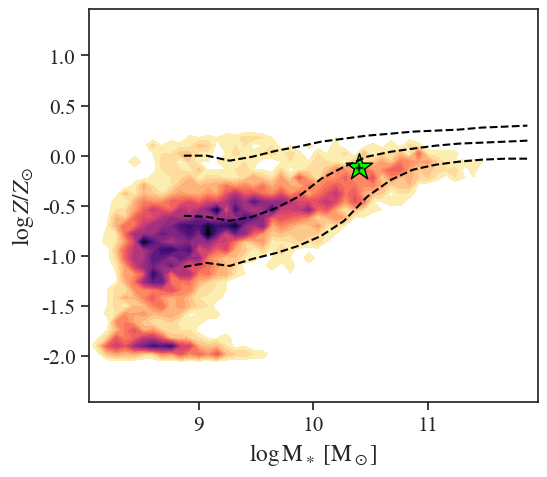

In [34]:
cmap = matplotlib.cm.get_cmap('magma_r')
colors = ["white", "white", "white"]+[cmap(i/100) for i in range(100)]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)


fig = plt.figure(figsize=(8, 7)); grid = plt.GridSpec(4, 4, hspace=0.45, wspace=0.6); ax = fig.add_subplot(grid[:-1, 1:])

# Background galaxy distribution from COSMOS
counts, xedges, yedges = np.histogram2d(list(cosmos_data["Mass"]), list(cosmos_data["massmet_2_median"]), bins=(50, 50), range=[[8, 12], [-2.5, 1.5]])
xs = (xedges[:-1] + xedges[1:]) / 2
ys = (yedges[:-1] + yedges[1:]) / 2
mplt = ax.contourf(xs, ys, counts.transpose(), 30, cmap=cmap)

# Mass-Metallicity relation from Gallazzi+2005
massmet = np.loadtxt('data/gallazzi_05_massmet.txt')
ax.plot(massmet[:, 0], massmet[:, 2], color="black", ls="--")
ax.plot(massmet[:, 0], massmet[:, 1], color="black", ls="--")
ax.plot(massmet[:, 0], massmet[:, 3], color="black", ls="--")

# FRB Mizu measurements
ax.errorbar([10.3985], [-.1168], xerr=[0.0038], yerr=[0.008], fmt="*", color="lime", alpha=0.75,
            capsize=3, ecolor="black", elinewidth=0.5, markeredgecolor="black", markersize=1)
ax.scatter([10.3985], [-.1168],  color="lime", alpha=1, norm=matplotlib.colors.LogNorm(), marker="*", s=400, edgecolors='black')

ax.set_xlabel(r"$\log{{\mathrm{M}}_\ast}~[{\mathrm{M}}_\odot]$")
ax.set_ylabel(r"$\log{Z/Z_{\odot}}$")


## Galaxy Star-Forming Main Sequence

The star-forming main sequence is the tight, nearly linear correlation observed between a galaxy's stellar mass ($M_\ast$) and its star-formation rate (SFR). Galaxies lying along this relation are considered "main-sequence" star-forming galaxies, while those significantly above or below it are classified as starbursts or quenched systems, respectively. The SFMS evolves with redshift, such that galaxies at earlier cosmic times exhibit higher SFRs at fixed stellar mass. Quantitatively, the SFMS can be parameterized as a broken power law in stellar mass with slopes $a$ and $b$ above and below a characteristic turnover mass $M_t$: 
\begin{equation}
    \log (\mathrm{SFR}) = 
    \begin{cases}
        a \left( \log M_\ast - \log M_t \right) + c, & \log M_\ast > \log M_t \\
        b \left( \log M_\ast - \log M_t \right) + c, & \log M_\ast \leq \log M_t,
    \end{cases}
\end{equation}
where $c$ is the intercept. The parameters $(a, b, c, M_t)$ vary with redshift and capture the redshift evolution of the SFMS ([Leja+2022](https://ui.adsabs.harvard.edu/abs/2022ApJ...936..165L/abstract)). 

In [35]:
def generate_gal_sfms(logM_sample, z0):
    # Continuity model median parameters + 1-sigma uncertainties.
    pars = {'a': [-0.06707, 0.3684, -0.1047],
            'a_err': [0., 0., 0.],
            'b': [0.8552, -0.1010, -0.001816],
            'b_err': [0., 0., 0.],
            'c': [0.2148, 0.8137, -0.08052],
            'c_err': [0., 0., 0.],
            'logMt': [10.29, -0.1284, 0.1203],
            'logMt_err': [0., 0., 0.]
            }

    logMt_sample = np.random.normal(pars["logMt"][0], pars["logMt_err"][0]) + (z0*np.random.normal(pars["logMt"][1], pars["logMt_err"][1])) + (z0*(np.random.normal(pars["logMt"][2], pars["logMt_err"][2])**2))
    a_sample = np.random.normal(pars["a"][0], pars["a_err"][0]) + (z0*np.random.normal(pars["a"][1], pars["a_err"][1])) + (z0*(np.random.normal(pars["a"][2], pars["a_err"][2])**2))
    b_sample = np.random.normal(pars["b"][0], pars["b_err"][0]) + (z0*np.random.normal(pars["b"][1], pars["b_err"][1])) + (z0*(np.random.normal(pars["b"][2], pars["b_err"][2])**2))
    c_sample = np.random.normal(pars["c"][0], pars["c_err"][0]) + (z0*np.random.normal(pars["c"][1], pars["c_err"][1])) + (z0*(np.random.normal(pars["c"][2], pars["c_err"][2])**2))

    if logM_sample > logMt_sample:
        logSFR_sample = a_sample*(logM_sample-logMt_sample) + c_sample
    else:
        logSFR_sample = b_sample*(logM_sample-logMt_sample) + c_sample
    return logSFR_sample


Text(0, 0.5, 'log SFR$_{\\rm{100 Myr}}~[{\\mathrm{M}}_\\odot/$yr]')

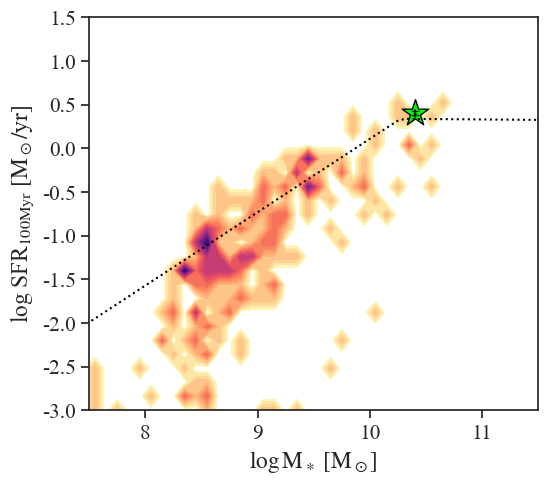

In [36]:
fig = plt.figure(figsize=(8, 7)); grid = plt.GridSpec(4, 4, hspace=0.45, wspace=0.6); ax = fig.add_subplot(grid[:-1, 1:])

cosmos_data = cosmos_data[cosmos_data["z"]<0.1]

# Background galaxy distribution from COSMOS
counts, xedges, yedges = np.histogram2d(list(cosmos_data["Mass"]), list(cosmos_data["SFR"]), 
                                        bins=(50, 50), range=[[7, 12], [-5, 3]])
xs = (xedges[:-1] + xedges[1:]) / 2
ys = (yedges[:-1] + yedges[1:]) / 2
mplt = ax.contourf(xs, ys, counts.transpose(), 30, cmap=cmap)

# FRB Mizu measurements
ax.errorbar([10.3985], [0.4042], xerr=[0.0038], yerr=[0.0252], fmt="*", color="lime", alpha=0.75,
            capsize=3, ecolor="black", elinewidth=0.5, markeredgecolor="black", markersize=1)
ax.scatter([10.3985], [0.4042],  color="lime", alpha=1, norm=matplotlib.colors.LogNorm(), marker="*", s=400, edgecolors='black')

# Galaxy star-forming main sequence from Leja+2022
logm = np.linspace(6, 13, 100)
logSFRs = []
for logMstar in logm:
    logSFRs.append(generate_gal_sfms(logMstar, 0.15))
ax.plot(logm, logSFRs, color="black", ls="dotted")
 
ax.set_xlim(7.5, 11.5)
ax.set_ylim(-3, 1.5)

ax.set_xlabel(r"$\log{{\mathrm{M}}_\ast}~[{\mathrm{M}}_\odot]$")
ax.set_ylabel(r"log SFR$_{\rm{100 Myr}}~[{\mathrm{M}}_\odot/$yr]")



## Age-sSFR Relation

The median age–sSFR relation describes how the typical stellar population age of galaxies correlates with their specific star-formation rate (sSFR). Galaxies with high sSFR tend to have younger stellar populations, as recent star formation dominates their light. Conversely, galaxies with low sSFR typically show older median stellar ages, reflecting quenched or slowly evolving systems. This relation highlights the connection between a galaxy’s star-formation activity and its stellar population history, and is a key diagnostic in understanding galaxy evolution.

Text(0, 0.5, 'log sSFR [Gyr$^{-1}$]')

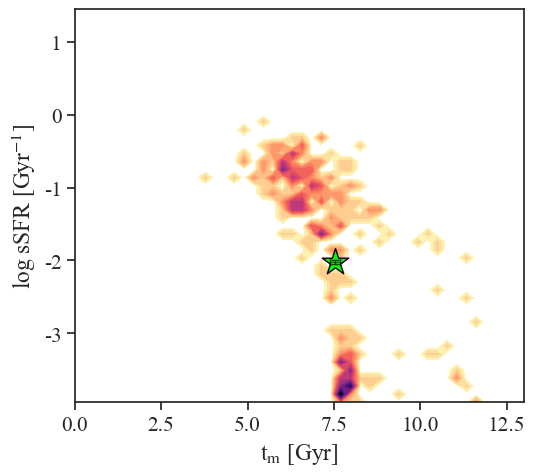

In [37]:
fig = plt.figure(figsize=(8, 7)); grid = plt.GridSpec(4, 4, hspace=0.45, wspace=0.6); ax = fig.add_subplot(grid[:-1, 1:])

# Background galaxy distribution from COSMOS
counts, xedges, yedges = np.histogram2d(list(cosmos_data["avg_age_median"]), list(np.array(cosmos_data["ssfr_100_median"])+9), 
                                        bins=(50, 50), range=[[0, 14], [-4, 1.5]])
counts /= len(list(cosmos_data["Mass"]))
xs = (xedges[:-1] + xedges[1:]) / 2
ys = (yedges[:-1] + yedges[1:]) / 2
mplt = ax.contourf(xs, ys, counts.transpose(), 30, cmap=cmap)

# FRB Mizu measurements
ax.errorbar([7.5399], [-2.017728766], xerr=[0.1434], yerr=[0.02632893], fmt="*", color="lime", alpha=0.75,
            capsize=3, ecolor="black", elinewidth=0.5, markeredgecolor="black", markersize=1)
ax.scatter([7.5399], [-2.017728766],  color="lime", alpha=1, norm=matplotlib.colors.LogNorm(), marker="*", s=400, edgecolors='black')

ax.set_xlim(0, 13)

ax.set_xlabel(r"t$_{\rm{m}}$ [Gyr]")
ax.set_ylabel(r"log sSFR [Gyr$^{-1}$]")
